### Import the required libraries

In [73]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Load the dataset `USA_Housing.csv`

In [74]:
df = pd.read_csv('USA_Housing.csv')

### Perform some basic EDA operations like viewing top and last rows, checking for null values, viewing columns etc...

In [75]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [90]:
df.tail()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Area Population,Price
4995,60567.944140,7.830362,6.137356,22837.361035,1.060194e+06
4996,78491.275435,6.999135,6.576763,25616.115489,1.482618e+06
4997,63390.686886,7.250591,4.805081,33266.145490,1.030730e+06
4998,68001.331235,5.534388,7.130144,42625.620156,1.198657e+06
4999,65510.581804,5.992305,6.792336,46501.283803,1.298950e+06


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [92]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Area Population', 'Price'],
      dtype='object')

In [89]:
df.isnull().sum()

Avg. Area Income             0
Avg. Area House Age          0
Avg. Area Number of Rooms    0
Area Population              0
Price                        0
dtype: int64

### Let's do some visualization

### Shows how house prices are spread (normal, skewed, etc.).

In [ ]:
sns.histplot(df['Price'], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()


### Shows how income affects house price.

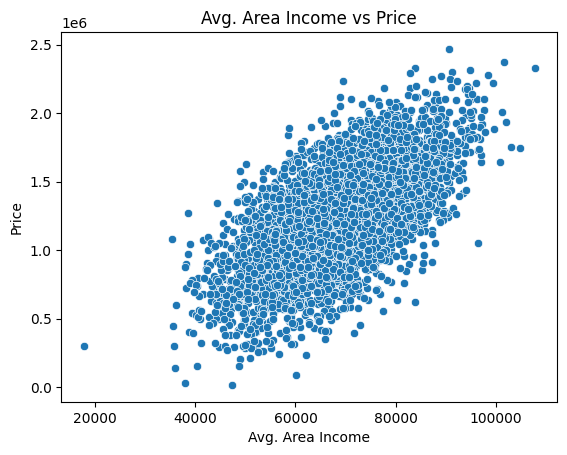

In [88]:
sns.scatterplot(x='Avg. Area Income', y='Price', data=df)
plt.title("Avg. Area Income vs Price")
plt.show()


### Checks whether older houses are cheaper or not.

In [ ]:
sns.scatterplot(x='Avg. Area House Age', y='Price', data=df)
plt.title("House Age vs Price")
plt.show()


### Shows how the number of rooms impacts price.

In [ ]:
sns.scatterplot(x='Avg. Area Number of Rooms', y='Price', data=df)
plt.title("Number of Rooms vs Price")
plt.show()


### Gives a quick overall relationship between numeric columns.

In [ ]:
corr = df[['Avg. Area Income', 'Avg. Area House Age', 
            'Avg. Area Number of Rooms', 'Price']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


### The two columns which are `Address` and `Avg. Area Number of Bedrooms` are of no use so we can remove it from our dataset.

In [ ]:
df.drop('Address',axis=1,inplace=True)
df.drop('Avg. Area Number of Bedrooms',axis=1,inplace=True)

### Now we have to predict the `Price` of the house so this is the time when we split our data into X and y features.

In [83]:
y = df["Price"]
X = df.drop(columns=["Price"])


### We split the data into training and testing sets, with 80% for training and 20% for testing.
### we will import train_test_split from sklearn.model_selection

In [84]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Create a Decision Tree Regressor `from sklearn.tree` and then train it using your training data (X_train, y_train).

In [93]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
model.fit(X_train, y_train)


,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


### Use your trained model to predict the target values for the unseen test data (X_test).

In [94]:
y_pred = model.predict(X_test)


### Check how well your model predicts by calculating the R² score from sklearn.metrices — it shows how much of the target’s variation is explained by your model.”

In [95]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(r2)

0.7409080184248802


Let's get some best parameters for our model and let's check what is the accuracy we are getting for our model for this we will use `RandomizedSearchCV` from `sklearn.model_selection`.

In [102]:
from sklearn.model_selection import RandomizedSearchCV

model = DecisionTreeRegressor(random_state=42)

param_dist = {
    'criterion': ['squared_error','absolute_error'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 5, 10, 15, 20, 25, 30],
    'min_samples_split': [2, 4, 6, 8, 10],
    'min_samples_leaf': [1, 2, 4, 6, 8]
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,              
    scoring='r2',           
    cv=5,                   
    random_state=42,
    n_jobs=-1               
)

random_search.fit(X_train, y_train)
print("Best Parameters:", random_search.best_params_)
print("Best R² Score:", random_search.best_score_)


Best Parameters: {'splitter': 'best', 'min_samples_split': 6, 'min_samples_leaf': 6, 'max_depth': 20, 'criterion': 'squared_error'}
Best R² Score: 0.8014011052612503
